<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/Transformer%2Bcnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

STEP 2: DATASET

In [2]:
DATASET_DIR = '/content/drive/MyDrive/ArsenicSkinImageBD/Original'

IMG_SIZE = (300, 300)
BATCH_SIZE = 32

STEP 3: DATA GENERATOR

In [3]:
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes
print("Classes:", train_generator.class_indices)

Found 1031 images belonging to 2 classes.
Found 257 images belonging to 2 classes.
Classes: {'infacted': 0, 'not_infacted': 1}


STEP 4: CNN + TRANSFORMER MODEL

In [4]:
def transformer_block(x, num_heads=4, key_dim=64):

    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim
    )(x, x)

    x1 = layers.Add()([x, attn])
    x1 = layers.LayerNormalization()(x1)

    ffn = layers.Dense(256, activation='gelu')(x1)
    ffn = layers.Dense(x.shape[-1])(ffn)

    x2 = layers.Add()([x1, ffn])
    x2 = layers.LayerNormalization()(x2)

    return x2

In [5]:
inputs = layers.Input(shape=(300,300,3))

base = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights='imagenet',
    input_tensor=inputs
)

base.trainable = False

x = base.output

h, w, c = x.shape[1], x.shape[2], x.shape[3]
patches = h * w

x = layers.Reshape((patches, c))(x)

pos = tf.range(start=0, limit=patches, delta=1)
pos_emb = layers.Embedding(patches, c)(pos)
x = x + pos_emb

# Transformer layers
x = transformer_block(x)
x = transformer_block(x)

x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 150, 150,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 150, 150,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 75, 75,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 75, 75,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 75, 75,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 75, 75,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 75, 75,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 75, 75,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 75, 75,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 75, 75,    │          0 │ block2b_expand_b

 Total params: 10,229,970 (39.02 MB)

 Trainable params: 4,310,658 (16.44 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

STEP 5: COMPILE

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

STEP 6: TRAIN (STAGE 1)

In [7]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1164s 35s/step - accuracy: 0.7420 - loss: 0.5070 - val_accuracy: 0.7276 - val_loss: 0.5135
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 385s 12s/step - accuracy: 0.9127 - loss: 0.2075 - val_accuracy: 0.7821 - val_loss: 0.4455
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 371s 11s/step - accuracy: 0.9534 - loss: 0.1192 - val_accuracy: 0.8132 - val_loss: 0.3788
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 395s 12s/step - accuracy: 0.9699 - loss: 0.0799 - val_accuracy: 0.8016 - val_loss: 0.5691
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 386s 12s/step - accuracy: 0.9758 - loss: 0.0774 - val_accuracy: 0.7977 - val_loss: 0.6656
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 381s 11s/step - accuracy: 0.9855 - loss: 0.0512 - val_accuracy: 0.7276 - val_loss: 1.3279
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 393s 12s/step - accuracy: 0.9835 - loss: 0.0577 - val_accuracy: 0.7938 - val_loss: 0.7360
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 395s 12s/step - accuracy: 0.9864 - loss: 0.0313 - val_accuracy: 0

STEP 7: FINE TUNING

In [8]:
base.trainable = True

for layer in base.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 478s 14s/step - accuracy: 0.9486 - loss: 0.1356 - val_accuracy: 0.7899 - val_loss: 0.5838
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 433s 13s/step - accuracy: 0.9631 - loss: 0.0884 - val_accuracy: 0.7899 - val_loss: 0.5462
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 421s 13s/step - accuracy: 0.9690 - loss: 0.0794 - val_accuracy: 0.7743 - val_loss: 0.6456
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 429s 13s/step - accuracy: 0.9825 - loss: 0.0649 - val_accuracy: 0.8327 - val_loss: 0.4830
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 429s 13s/step - accuracy: 0.9777 - loss: 0.0622 - val_accuracy: 0.8210 - val_loss: 0.5530


STEP 8: ACCURACY + LOSS CURVE

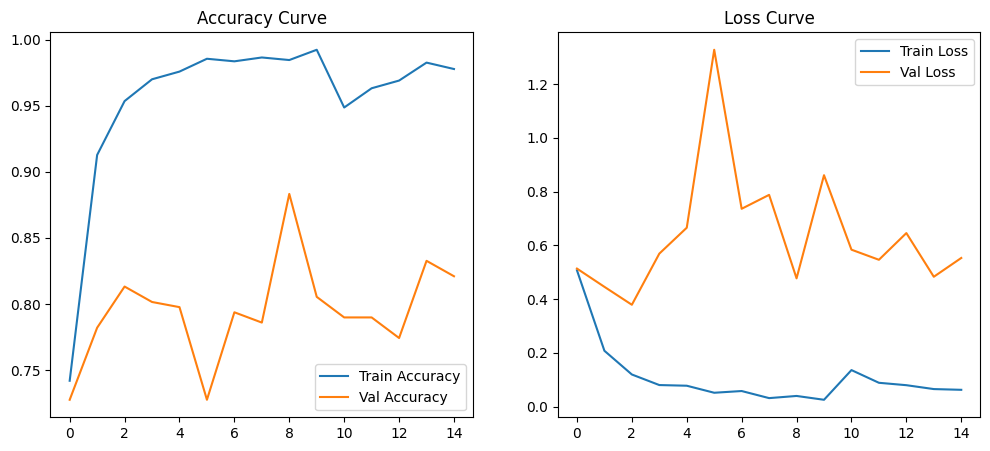

In [9]:
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")

plt.subplot(1,2,2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title("Loss Curve")

plt.show()

STEP 9: FINAL EVALUATION (YOUR REQUEST)

In [10]:
val_loss, val_acc = model.evaluate(val_generator)

print("=================================")
print("Final Validation Accuracy:", val_acc * 100)
print("=================================")

9/9 ━━━━━━━━━━━━━━━━━━━━ 65s 7s/step - accuracy: 0.8249 - loss: 0.4770
Final Validation Accuracy: 82.49027132987976


STEP 10: CONFUSION MATRIX

9/9 ━━━━━━━━━━━━━━━━━━━━ 65s 6s/step


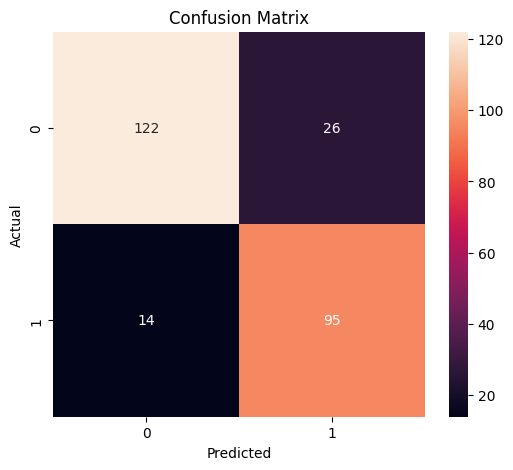

In [11]:
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

STEP 11: ROC CURVE

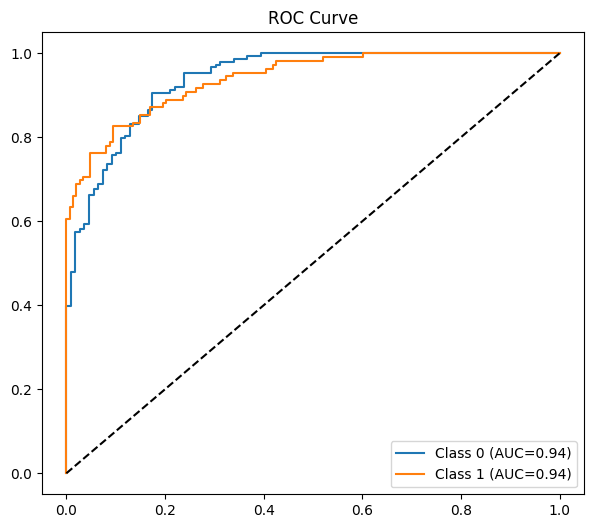

In [12]:
plt.figure(figsize=(7,6))

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true == i, y_pred[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC={auc_score:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.legend()
plt.show()